In [1]:
# --- imports
import pandas as pd
%load_ext autoreload
import segmentation_models_pytorch as smp
%autoreload 2
import numpy as np
import torch 
import copy

/home/tjdu/micromamba/envs/solar-forecasting-hk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from src.utils import (
    stratified_split_grouped_by_time,
    make_labels,
    compute_means,
    summarize_split_csi_mean
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.train_val_bc import(
    evaluate_on_test,
    evaluate_csi_and_ghi,
)
from src.model_moe import(
    train_moe_easy,gate_stats,
    gate_usage_by_time_bucket,
    plot_moe_sample_simple,
    evaluate_csi_ghi)

from src.plot import(
    plot_full_images_from_loader,plot_rmse_extremes_with_time_and_ghi
)
from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.utils import crop_back, pad_to_32
from src.model_Twin import(TwinFiLMUNetTiny_MoE,TwinFiLMUNetTiny_SpatialMoE)

In [3]:
bands_npz_name = "Data/bands/modeldata/bands_day_paired_30mins_new_fuzzy_no_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]

In [ ]:
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="Data/output/new_combined_10mins_with_elev_landmask_fuzzy.npz",
)

print("Saved:", out)
print("Final shape:", shape)

In [3]:
X, y = load_bands_and_cams(
    bands_npz_path="Data/output/new_combined_10mins_with_elev_landmask_fuzzy.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_day_paired_30mins_new_fuzzy_no_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (67638, 12, 50, 50)
y shape: (67638, 1, 50, 50)
X finite: True
y finite: True
X stats: min 0.0 max 804.1715698242188
y stats: min 0.048625361174345016 max 1.0


In [4]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_new_fuzzy_no_twillight.npz")
t = cams["time_min"]
cams_data = cams["data"]
print("paired samples:", len(t))
print("unique CAMS times:", len(np.unique(t)))
print("duplicates exist:", len(t) != len(np.unique(t)))


paired samples: 67638
unique CAMS times: 46277
duplicates exist: True


In [5]:
c0 = cams_data[:,0]   # (T,H,W)
c1 = cams_data[:,1]   # (T,H,W)
labels, stats = make_labels(c0, c1, y, tw_cs_thr=76, clear_thr=0.8, cloudy_thr=0.35)
idx_train, idx_val, idx_test = stratified_split_grouped_by_time(labels, t, 0.8, 0.1, 0.1, seed=42)
T = X.shape[0]
X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

train | N= 54101 | mean=0.6992 std=0.2686 | p05=0.1851 p50=0.7892 p95=0.9917 | min=0.0577 max=0.9997
  val | N=  6783 | mean=0.6975 std=0.2671 | p05=0.1872 p50=0.7808 p95=0.9916 | min=0.0588 max=0.9992
 test | N=  6754 | mean=0.6985 std=0.2688 | p05=0.1829 p50=0.7875 p95=0.9916 | min=0.0592 max=0.9977


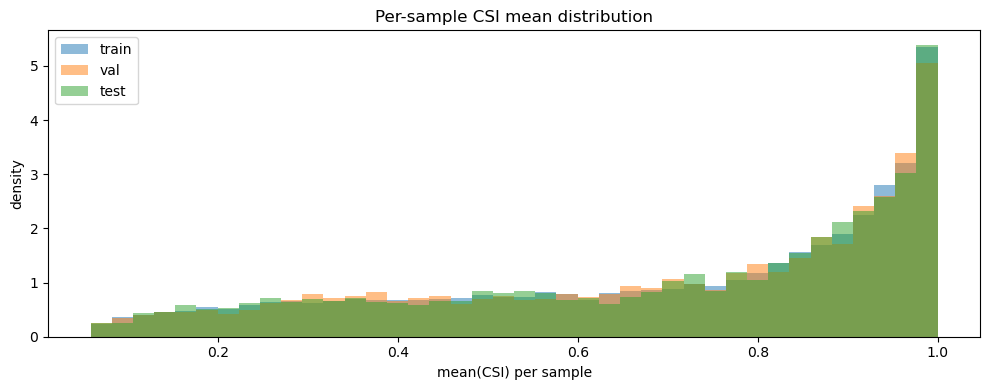

In [6]:
report = summarize_split_csi_mean(
    y,
    idx_train=idx_train,
    idx_val=idx_val,
    idx_test=idx_test,
    bins=40,
    plot=True
)

channel_mean: [238.66437  247.30698  254.30418  276.60678  259.0976   278.6026
 277.43613  274.47504  263.09882   39.706436  34.05114    0.3652  ]
channel_std: [ 9.577975   11.47075    12.711327   19.808594   12.378416   20.610844
 20.99358    20.233007   16.079489    0.3124471  80.81088     0.48147944]

In [7]:
# 4) compute per-channel min max on TRAIN only
#    X_train: (T_train, C, H, W)
channel_min = np.nanmin(X_train, axis=(0, 2, 3))   # (C,)
channel_max = np.nanmax(X_train, axis=(0, 2, 3))   # (C,)

# optional: protect against zero range channels
channel_range = channel_max - channel_min
channel_range[channel_range < 1e-6] = 1e-6

print("channel_min:", channel_min)
print("channel_max:", channel_max)
# save for night normalization later
np.savez(
    "Data/static/minmax_strat_stats_day_30mins_no_twillight_fuzzy_new_split.npz",
    channel_min=channel_min,
    channel_max=channel_max,
)

channel_min: [187.04999 183.7     185.03    182.54    208.81999 182.60999 181.82
 182.57999 185.31999  38.89      0.        0.     ]
channel_max: [258.57     268.59     272.9      307.63     279.22     311.44998
 310.09     302.99     281.3       40.579998 804.1716     1.      ]


In [8]:
from torch.utils.data import DataLoader

train_dataset = BandsCamsDataset(X_train, y_train, channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
val_dataset   = BandsCamsDataset(X_val,   y_val,   channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
test_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=8, pin_memory=True,
    persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [24]:
! export CUDA_VISIBLE_DEVICES=0 

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)
from src.model_Twin import TwinFiLMUNetTiny,TwinFiLMUNetTiny_SpatialMoE
model = TwinFiLMUNetTiny_SpatialMoE(feature_size=48, K=2, gate_temp=0.5).to(device)
print(gate_stats(model, val_loader, device, K=2))

{'hard_usage': array([0.11426697, 0.885733  ], dtype=float32), 'mean_max_weight': 0.6220916420221329, 'mean_entropy': 0.6465353280305862}


In [10]:
model = TwinFiLMUNetTiny_SpatialMoE(feature_size=48, K=2, gate_temp=2.0).to(device)
print(model.K, len(model.experts), model.gate[-1].out_channels)

xb, yb = next(iter(train_loader))
xb = xb.to(device)
xb_pad, h, w = pad_to_32(xb)
y_hat, g = model(xb_pad)
print("y_hat:", y_hat.shape, "g:", g.shape)


2 2 2
y_hat: torch.Size([64, 1, 64, 64]) g: torch.Size([64, 2, 64, 64])


In [ ]:
best_ckpt = train_moe_easy(
    model, train_loader, val_loader, device,
    total_epochs=2,
    lr=1e-4, max_lr=3e-4,
    weight_decay=1e-3,
    lam_bal=0.001,
    full_val_every=5,
    val_batches_quick=30,
    ckpt_name="best_moe_easy_2.pt"
)

/home/tjdu/Solar-Forecasting-over-Hong-Kong-Region/src/model_moe.py:171: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Ep 001/2 | temp=2.00 | train_loss=0.11083 | quick_rmse=0.18211 | H=0.546 | usage=[0.539 0.461] | lr=1.76e-04 | 76.0s | FULL_rmse=0.17221 (best=0.17221)
Ep 002/2 | temp=2.00 | train_loss=0.07565 | quick_rmse=0.12775 | H=0.567 | usage=[0.485 0.515] | lr=3.00e-07 | 76.4s | FULL_rmse=0.13013 (best=0.13013)
Best ckpt: Model_checkpoint/best_moe_easy_2.pt best_full_rmse: 0.13012700790768184


In [12]:
# usage
metrics = evaluate_on_test(model, test_loader, device)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

RMSE: 0.130721
rRMSE: 0.187138
R2: 0.826233
MBE: 0.009201
MAE: 0.084770
mean_true: 0.698530


In [13]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_new_fuzzy_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)
ghi_cs_all = cams_data[:, 1, :, :]   # c1 = clear-sky GHI, shape (T, H, W)
ghi_cs_test = ghi_cs_all[idx_test]   # shape (N_test, H, W)
# if you want explicit channel dim:
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (N_test, 1, H, W)


swin
{'CSI_RMSE': 0.1379673331975937,
 'CSI_rRMSE': 0.19519218802452087,
 'CSI_R2': 0.7941124439239502,
 'CSI_MBE': 0.01562388613820076,
 'CSI_MAE': 0.08873958885669708,
 'CSI_mean_true': 0.7068281769752502,
 'GHI_RMSE': 78.64848327636719,
 'GHI_rRMSE': 0.1939978450536728,
 'GHI_R2': 0.9189393520355225,
 'GHI_MBE': 13.343442916870117,
 'GHI_MAE': 46.85791015625,
 'GHI_mean_true': 405.4090576171875}

In [14]:
metrics = evaluate_csi_and_ghi(model, test_loader, device, ghi_cs_test)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

CSI_RMSE: 0.130721
CSI_rRMSE: 0.187138
CSI_R2: 0.826233
CSI_MBE: 0.009201
CSI_MAE: 0.084770
CSI_mean_true: 0.698530
GHI_RMSE: 19.575703
GHI_rRMSE: 0.190643
GHI_R2: 0.917236
GHI_MBE: 1.885011
GHI_MAE: 11.767488
GHI_mean_true: 102.682755


In [16]:
print("gate_temp:", model.gate_temp)
print("eval mode:", not model.training)
print("gate_temp:", getattr(model, "gate_temp", None), "training:", model.training)


gate_temp: 2.0
eval mode: True
gate_temp: 2.0 training: False


CSI_RMSE: 0.133899
CSI_rRMSE: 0.189436
CSI_R2: 0.806077
CSI_MBE: 0.008085
CSI_MAE: 0.086178
CSI_mean_true: 0.706828
GHI_RMSE: 76.838295
GHI_rRMSE: 0.189533
GHI_R2: 0.922628
GHI_MBE: 8.518705
GHI_MAE: 45.806358
GHI_mean_true: 405.409058

In [17]:
PATH = "Model_checkpoint/best_moe_easy_2.pt" #"Model_checkpoint/best_moe.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# torch.save(model.state_dict(), PATH)

In [19]:
m2 = TwinFiLMUNetTiny_SpatialMoE(feature_size=48, K=2, gate_temp=2).to(device)
sd = torch.load(PATH, map_location=device)["model"]
m2.load_state_dict(sd)
m2.eval()

print("m2 temp:", m2.gate_temp)

metrics1 = evaluate_csi_and_ghi(model, test_loader, device, ghi_cs_test)
metrics2 = evaluate_csi_and_ghi(m2, test_loader, device, ghi_cs_test)
print(metrics1)
print(metrics2)

m2 temp: 2.0
{'CSI_RMSE': 0.13072115182876587, 'CSI_rRMSE': 0.18713754415512085, 'CSI_R2': 0.8262329697608948, 'CSI_MBE': 0.009200595319271088, 'CSI_MAE': 0.08476969599723816, 'CSI_mean_true': 0.6985297799110413, 'GHI_RMSE': 19.575702667236328, 'GHI_rRMSE': 0.1906425505876541, 'GHI_R2': 0.9172362089157104, 'GHI_MBE': 1.8850111961364746, 'GHI_MAE': 11.767487525939941, 'GHI_mean_true': 102.68275451660156}
{'CSI_RMSE': 0.13072115182876587, 'CSI_rRMSE': 0.18713754415512085, 'CSI_R2': 0.8262329697608948, 'CSI_MBE': 0.009200595319271088, 'CSI_MAE': 0.08476969599723816, 'CSI_mean_true': 0.6985297799110413, 'GHI_RMSE': 19.575702667236328, 'GHI_rRMSE': 0.1906425505876541, 'GHI_R2': 0.9172362089157104, 'GHI_MBE': 1.8850111961364746, 'GHI_MAE': 11.767487525939941, 'GHI_mean_true': 102.68275451660156}


In [20]:
PATH = "Model_checkpoint/best_moe_easy_2.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = TwinFiLMUNetTiny_SpatialMoE(feature_size=48, K=2, gate_temp=2).to(device)  # set final temp here
ckpt = torch.load(PATH, map_location=device)

sd = ckpt["model"]
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}

model.load_state_dict(sd, strict=True)
model.eval()

metrics = evaluate_csi_and_ghi(model, test_loader, device, ghi_cs_test)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

CSI_RMSE: 0.130721
CSI_rRMSE: 0.187138
CSI_R2: 0.826233
CSI_MBE: 0.009201
CSI_MAE: 0.084770
CSI_mean_true: 0.698530
GHI_RMSE: 19.575703
GHI_rRMSE: 0.190643
GHI_R2: 0.917236
GHI_MBE: 1.885011
GHI_MAE: 11.767488
GHI_mean_true: 102.682755


In [23]:
model = TwinFiLMUNetTiny_SpatialMoE(feature_size=48, K=2, gate_temp=2).to(device)
ckpt = torch.load(PATH, map_location=device)
sd = ckpt["model"]
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
model.load_state_dict(sd, strict=True)


<All keys matched successfully>

In [24]:
metrics = evaluate_csi_and_ghi(model, test_loader, device, ghi_cs_test)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")


CSI_RMSE: 0.130721
CSI_rRMSE: 0.187138
CSI_R2: 0.826233
CSI_MBE: 0.009201
CSI_MAE: 0.084770
CSI_mean_true: 0.698530
GHI_RMSE: 19.575703
GHI_rRMSE: 0.190643
GHI_R2: 0.917236
GHI_MBE: 1.885011
GHI_MAE: 11.767488
GHI_mean_true: 102.682755


In [ ]:
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=20,
    seed=5
)

In [25]:
import numpy as np
import torch

@torch.no_grad()
def rmse_by_time_bucket(model, test_loader, device, time_mins, idx_test):
    model.eval()
    time_test = np.asarray(time_mins)[np.asarray(idx_test)]  # unix minutes UTC

    # collect preds/truth in dataset order
    y_true_list, y_pred_list = [], []
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device).contiguous()
        xb_pad, h, w = pad_to_32(xb)
        y_hat,_ = model(xb_pad)
        y_hat = crop_back(y_hat, h, w).contiguous()
        y_true_list.append(yb.cpu().numpy())
        y_pred_list.append(y_hat.cpu().numpy())

    y_true = np.concatenate(y_true_list, 0).astype(np.float64)
    y_pred = np.concatenate(y_pred_list, 0).astype(np.float64)

    # convert to HKT minutes-of-day
    tod_hkt = (time_test + 8*60) % 1440  # HKT = UTC+8
    # define buckets (adjust if you want)
    buckets = {
        "night(00-05)": (0, 300),
        "morning(05-08)": (300, 480),
        "day(08-16)": (480, 960),
        "evening(16-19)": (960, 1140),
        "twilight/late(19-24)": (1140, 1440),
    }

    report = {}
    err = (y_pred - y_true)
    se  = err**2

    for name, (a,b) in buckets.items():
        m = (tod_hkt >= a) & (tod_hkt < b)
        if m.sum() == 0:
            report[name] = None
            continue
        rmse = float(np.sqrt(np.mean(se[m])))
        mae  = float(np.mean(np.abs(err[m])))
        mbe  = float(np.mean(err[m]))
        report[name] = {"N": int(m.sum()), "RMSE": rmse, "MAE": mae, "MBE": mbe}

    return report


In [26]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_new_fuzzy_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)
time_mins = cams["time_min"] 
ghi_cs_all = cams_data[:, 1, :, :]   # c1 = clear-sky GHI, shape (T, H, W)
ghi_cs_test = ghi_cs_all[idx_test]   # shape (N_test, H, W)
# if you want explicit channel dim:
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (N_test, 1, H, W)

rep = rmse_by_time_bucket(model, test_loader, device, time_mins, idx_test)
for k,v in rep.items():
    print(k, v)


night(00-05) None
morning(05-08) {'N': 561, 'RMSE': 0.1638347071535465, 'MAE': 0.1085068290413515, 'MBE': -0.0013518748127760733}
day(08-16) {'N': 5116, 'RMSE': 0.123141550359354, 'MAE': 0.07981615144262051, 'MBE': 0.01168504260039602}
evening(16-19) {'N': 1077, 'RMSE': 0.1454222895263274, 'MAE': 0.09593618374704319, 'MBE': 0.002895540273372177}
twilight/late(19-24) None


In [ ]:
sel, rmse_i = plot_rmse_extremes_with_time_and_ghi(
    model, test_loader, device,
    ghi_cs_test=ghi_cs_test,
    time_mins=time_mins,
    idx_test=idx_test,
    k=10, mode="worst",
    per_fig=10,
    bins=60,
    show_pixel_error_hist=True,
    show_utc=False,   # True 的話 title 同時顯示 UTC + HKT
)

In [ ]:
from src.plot import(
    plot_rmse_extremes_with_time_and_ghi
)
sel, rmse_i = plot_rmse_extremes_with_time_and_ghi(
    model, test_loader, device,
    ghi_cs_test=ghi_cs_test,
    time_mins=time_mins,
    idx_test=idx_test,
    k=10, mode="best",
    per_fig=10,
    bins=60,
    show_pixel_error_hist=True,
    show_utc=False,   # True 的話 title 同時顯示 UTC + HKT
)


In [ ]:
gate_usage_by_time_bucket(
    model, test_loader, device, time_mins, idx_test,
    buckets={
        "night(00-05)": (0, 300),
        "morning(05-08)": (300, 480),   
        "day(08-16)": (480, 960),
        "evening(16-19)": (960, 1140)
    }
)

night(00-05) None
morning(05-08) {'N': 561, 'RMSE': 0.12379330164297414, 'MAE': 0.07971081288521462, 'MBE': -0.007899925275736634}
day(08-16) {'N': 5116, 'RMSE': 0.08494543445805533, 'MAE': 0.054423048709478866, 'MBE': 0.005732069870975506}
evening(16-19) {'N': 1077, 'RMSE': 0.10169457474244638, 'MAE': 0.06613009332813177, 'MBE': 0.006519820621234737}
twilight/late(19-24) None

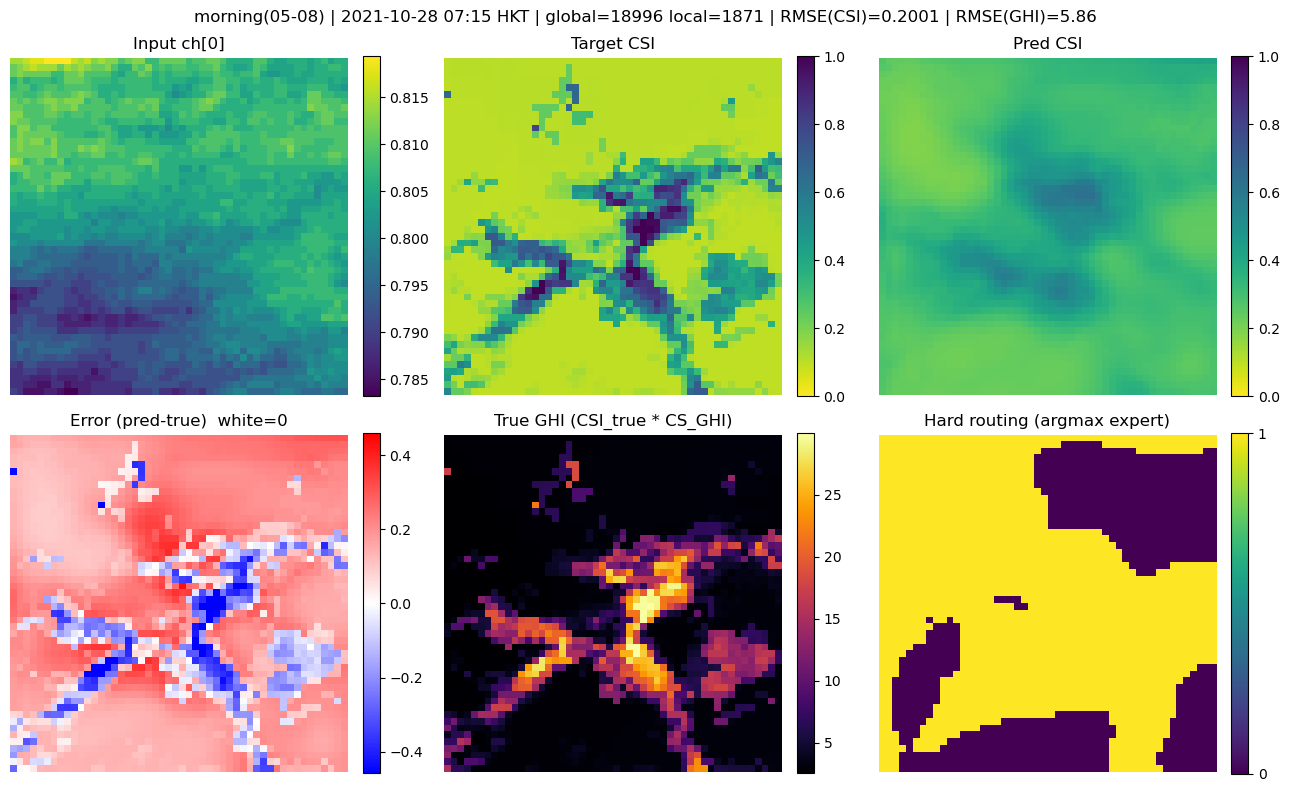

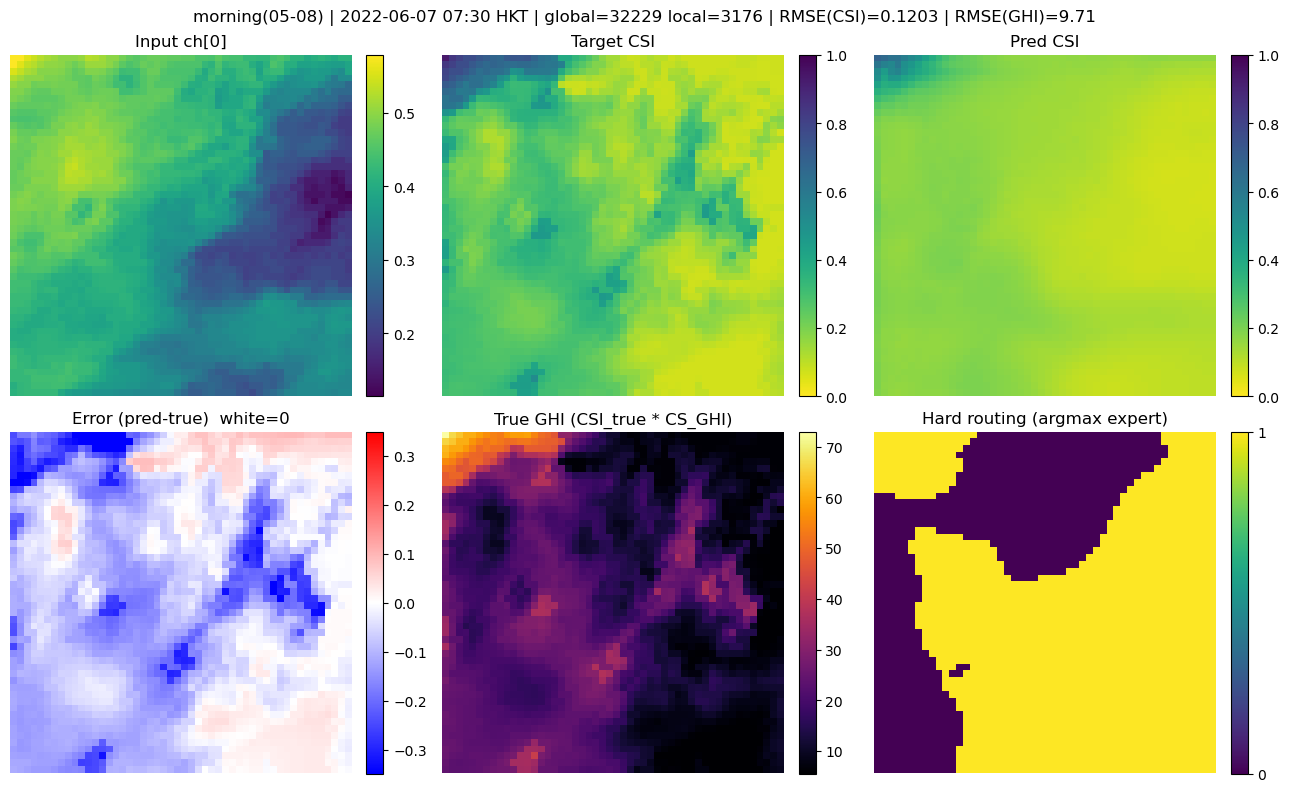

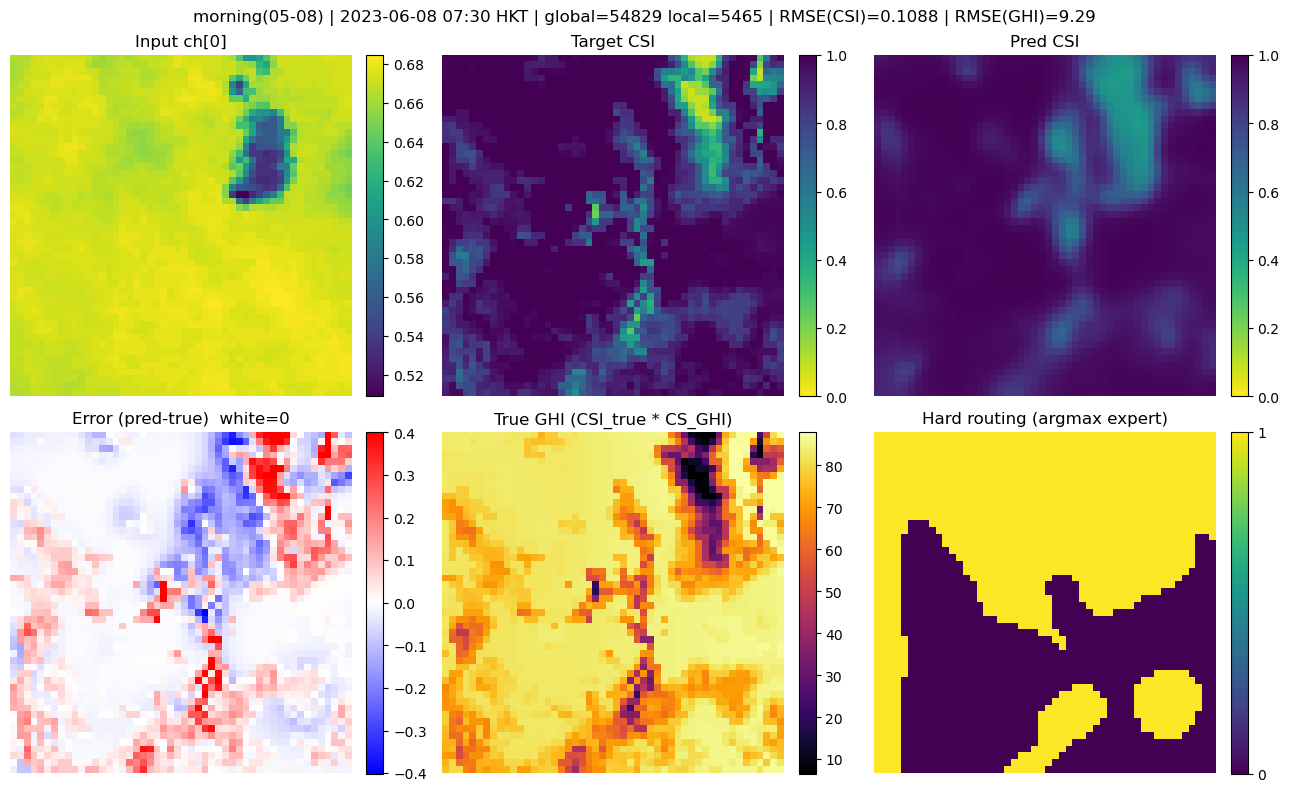

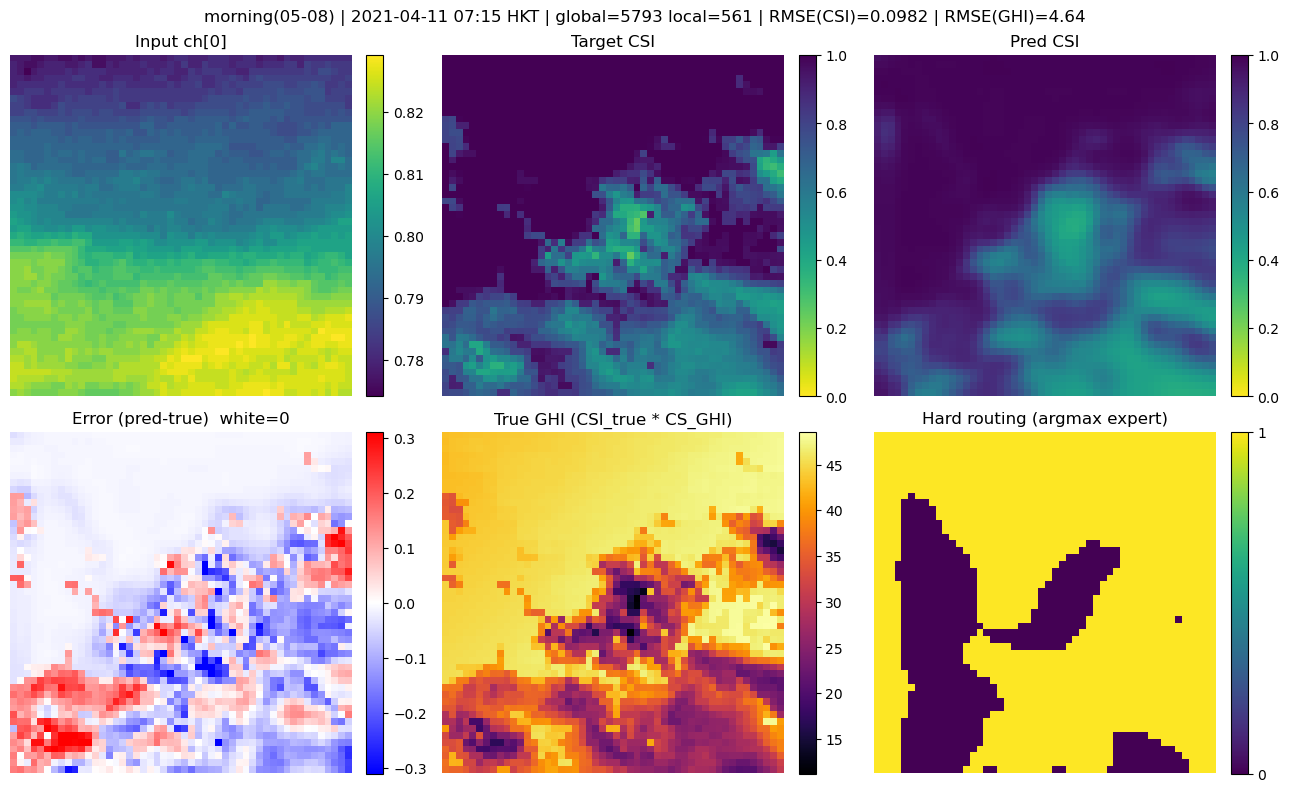

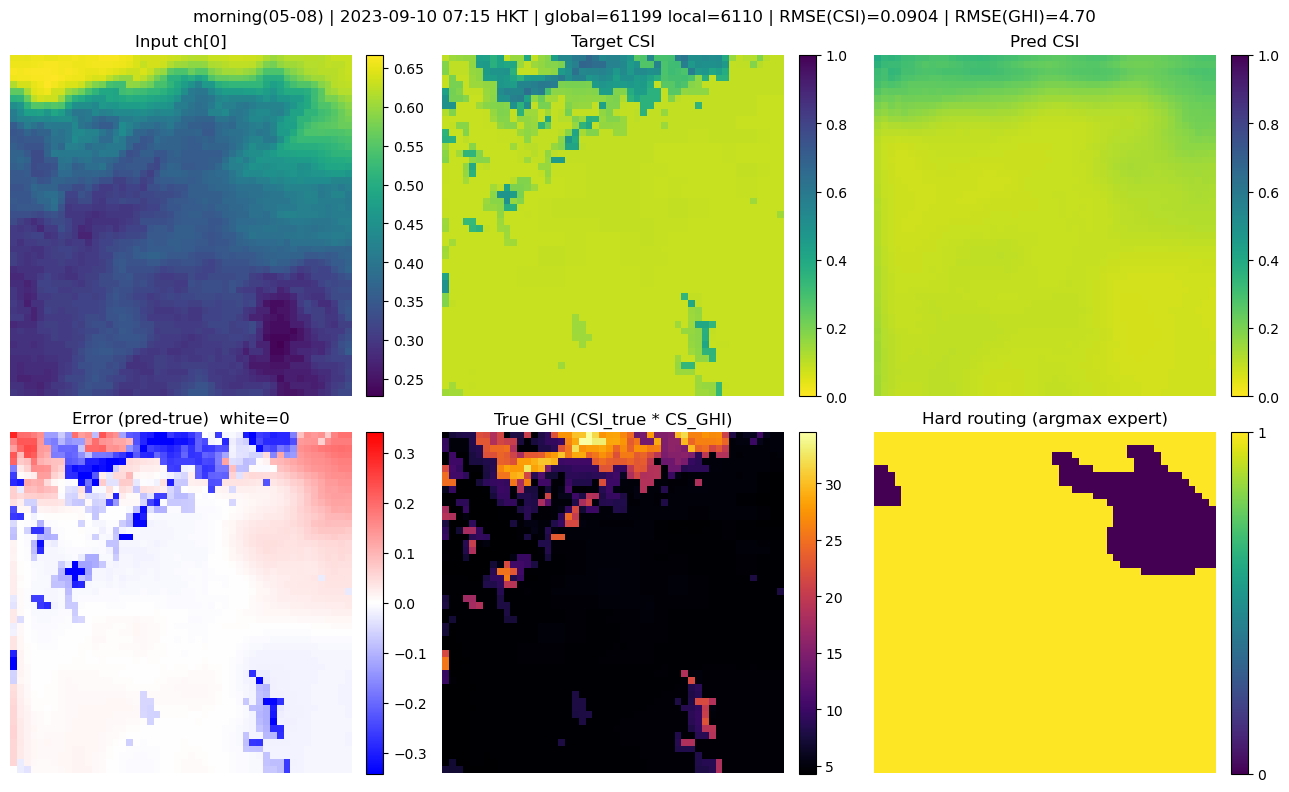

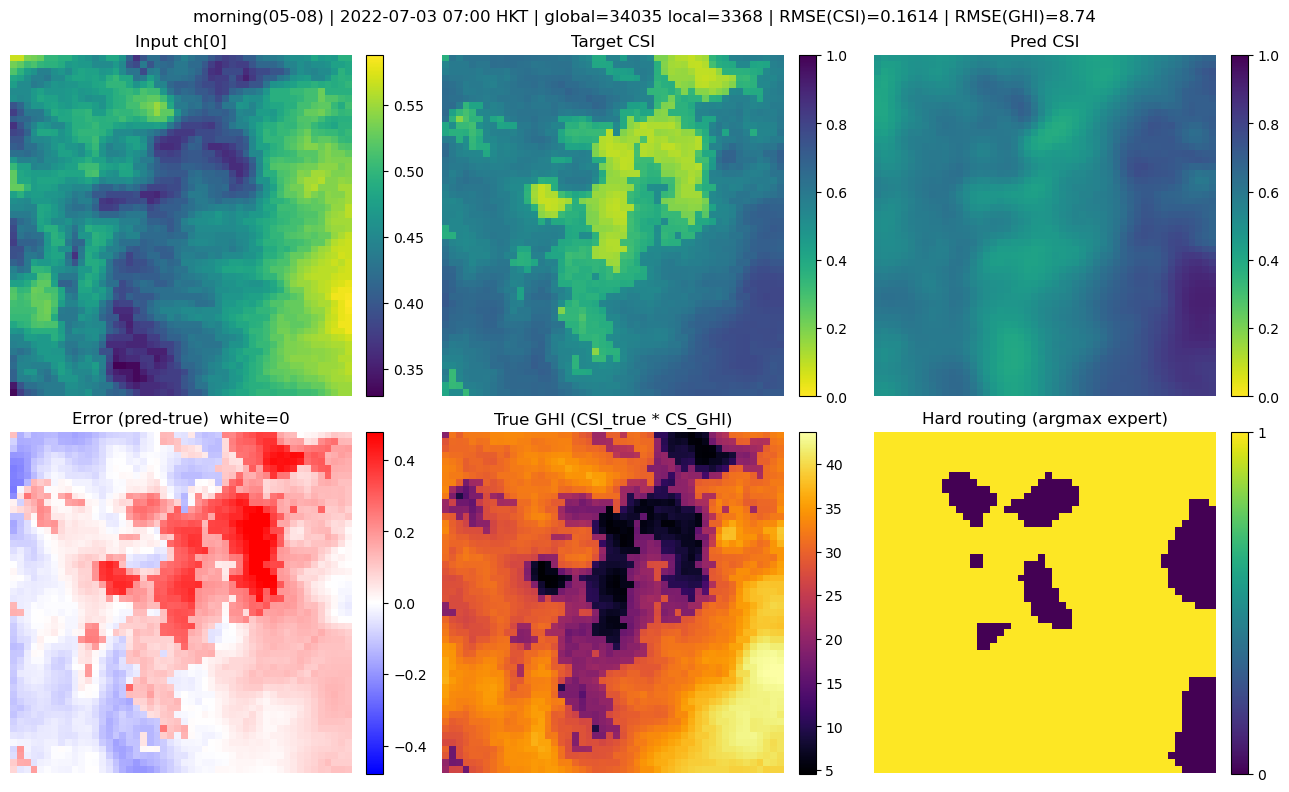

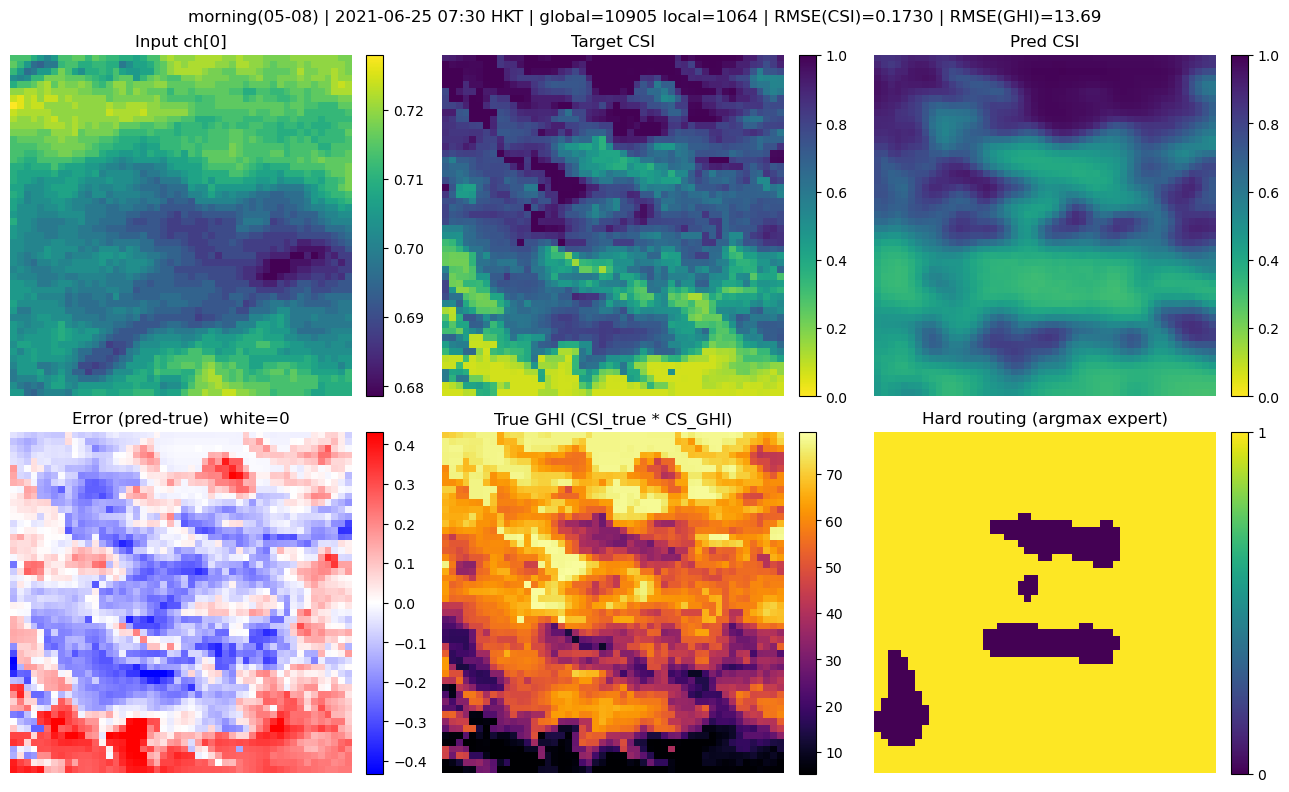

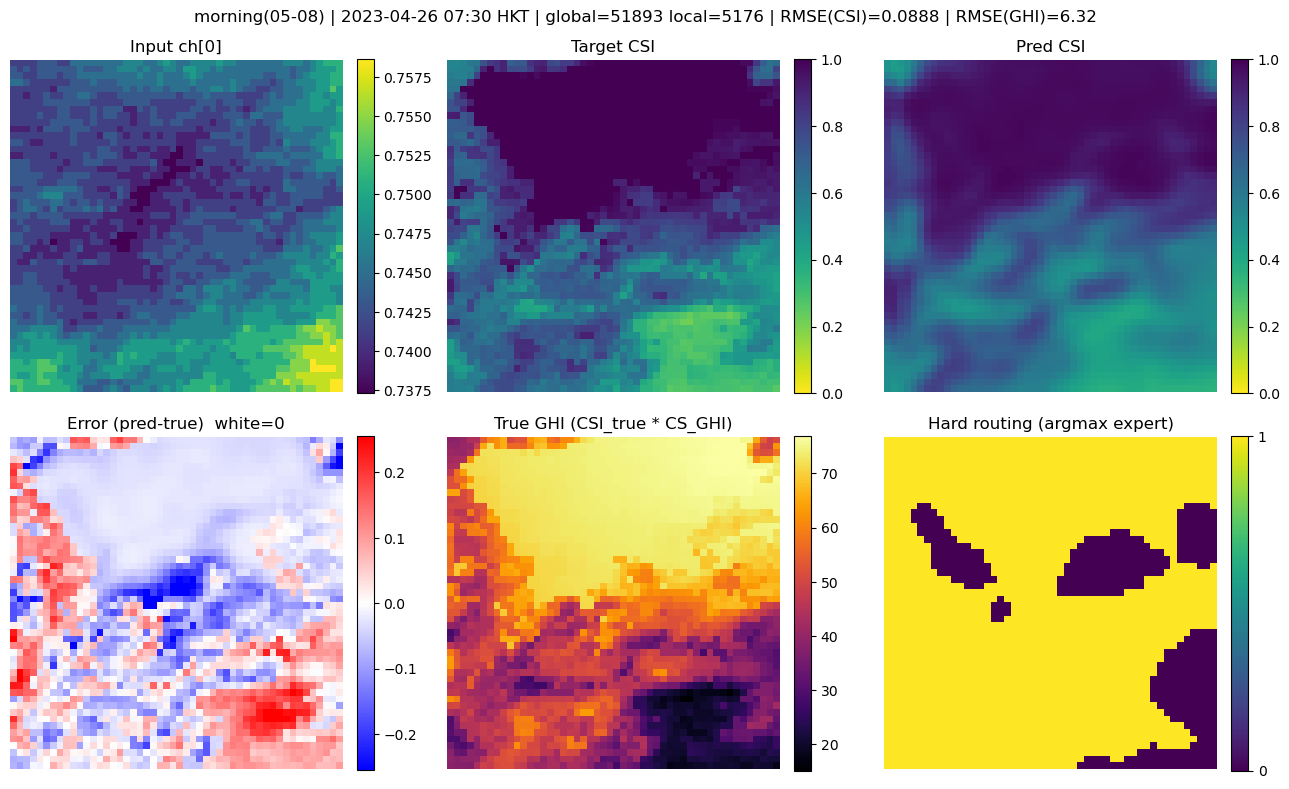

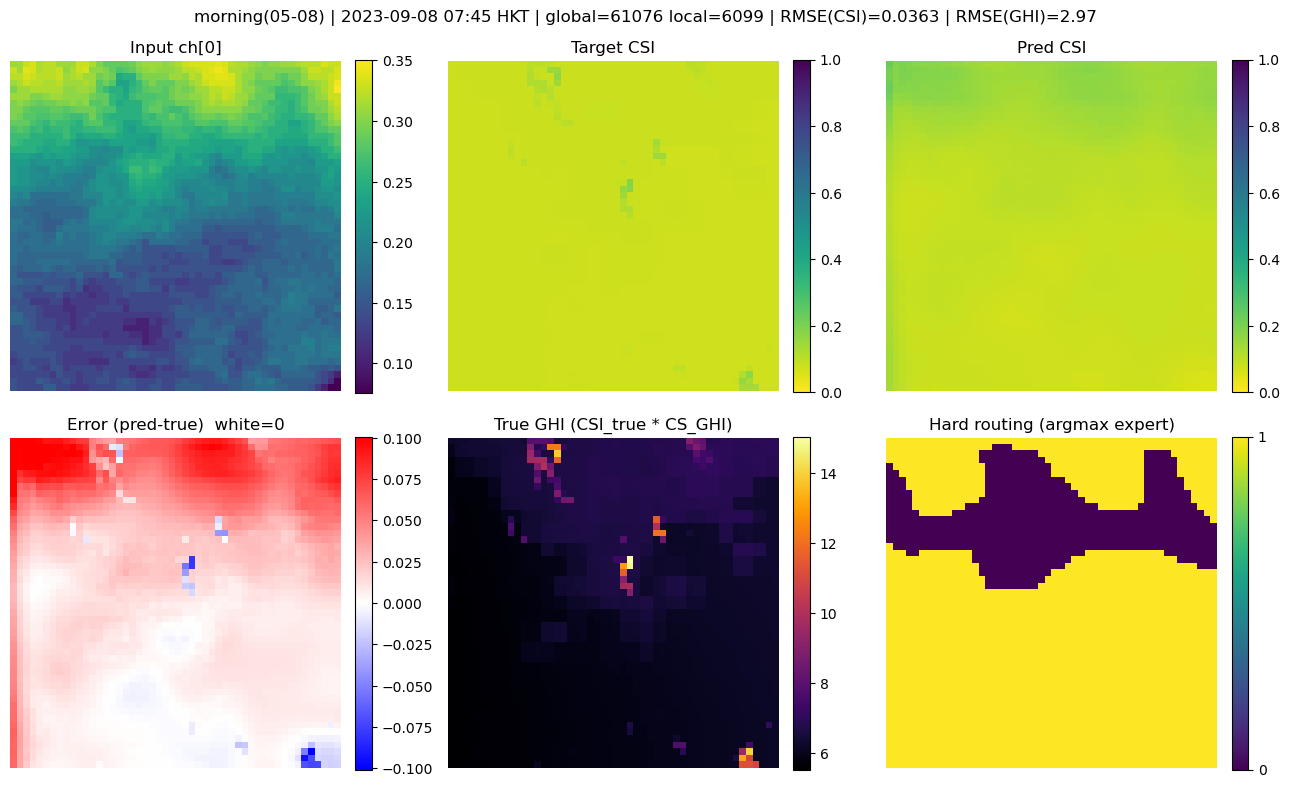

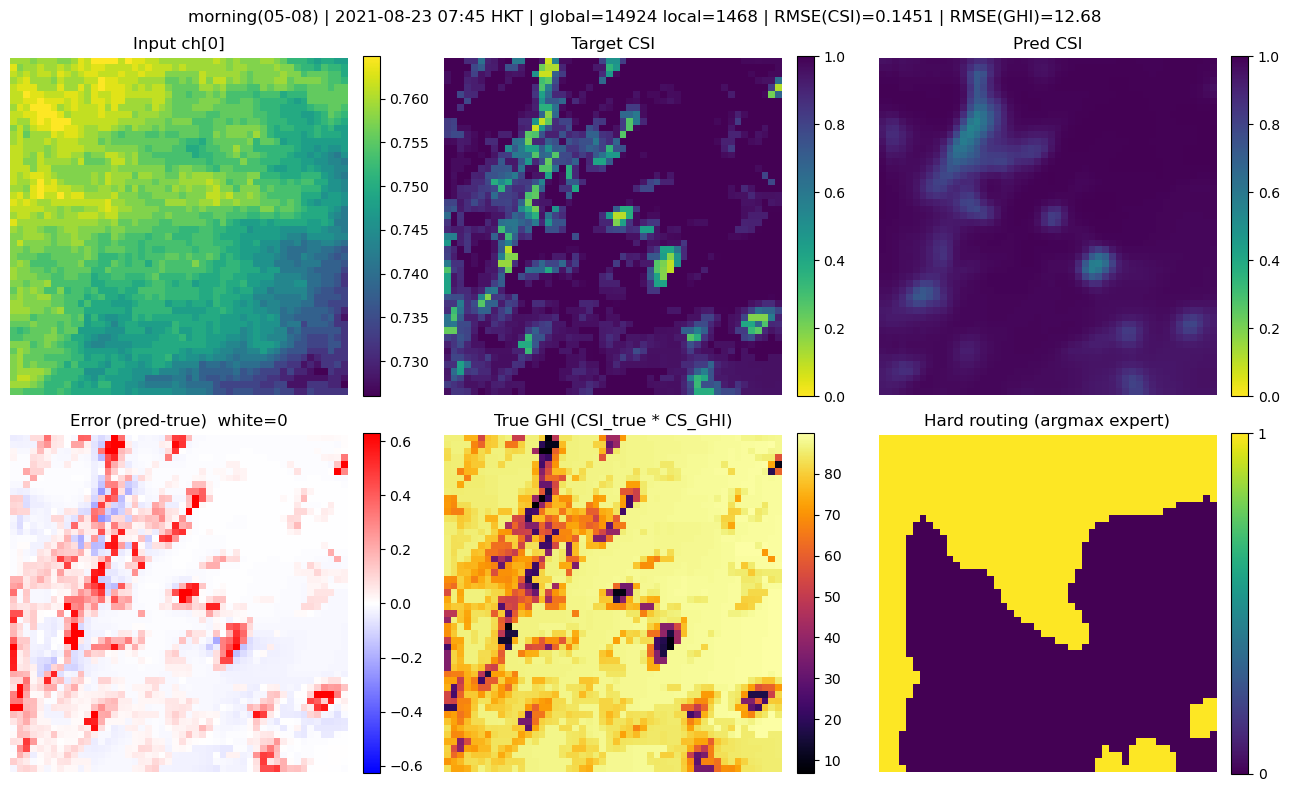

In [35]:
def pick_test_local_by_hkt_bucket(time_mins, idx_test, a, b, n=3, seed=0):
    rng = np.random.default_rng(seed)
    idx_test = np.asarray(idx_test)
    t = np.asarray(time_mins)[idx_test]         # test times in global order
    tod = (t + 8*60) % 1440                     # HKT minutes-of-day
    mask = (tod >= a) & (tod < b)
    local_candidates = np.where(mask)[0]        # LOCAL indices in test_dataset
    if len(local_candidates) == 0:
        return []
    n = min(n, len(local_candidates))
    return rng.choice(local_candidates, size=n, replace=False).tolist()

buckets = {
    "morning(05-08)": (300, 480),
    "day(08-16)": (480, 960),
    "evening(16-19)": (960, 1140),
}

expert_names = ["day", "twilight"]  # K=2

morning_local = pick_test_local_by_hkt_bucket(time_mins, idx_test, 300, 480, n=10, seed=1)
day_local     = pick_test_local_by_hkt_bucket(time_mins, idx_test, 480, 960, n=10, seed=1)
evening_local = pick_test_local_by_hkt_bucket(time_mins, idx_test, 960, 1140, n=10, seed=1)


for i in morning_local[:50]:
    plot_moe_sample_simple(
        model, test_dataset, i, device,
        time_mins=time_mins, idx_test=idx_test,
        cs_ghi_full=c1,            # <-- clear-sky GHI map per sample (global)
        bucket_name="morning(05-08)",
        x_vis_ch=0,
        cmap_csi="viridis_r"
    )


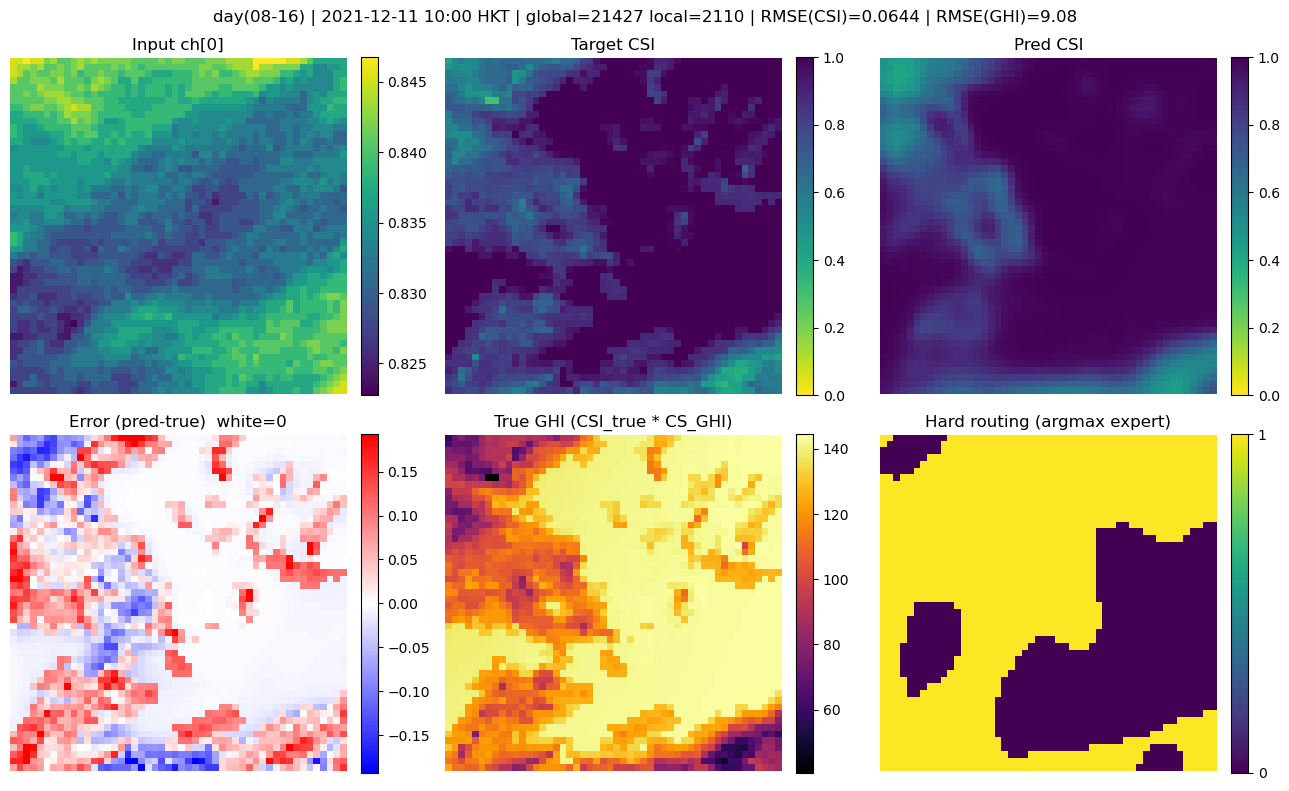

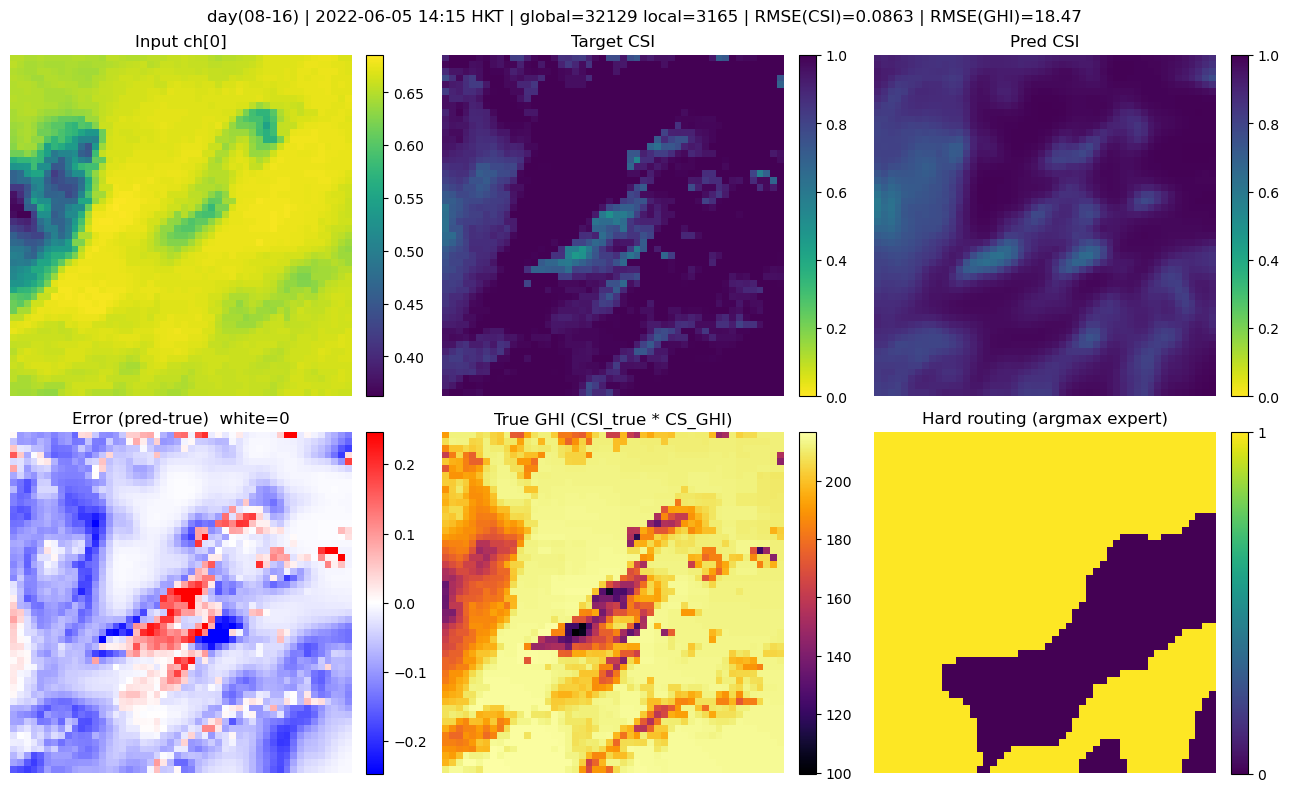

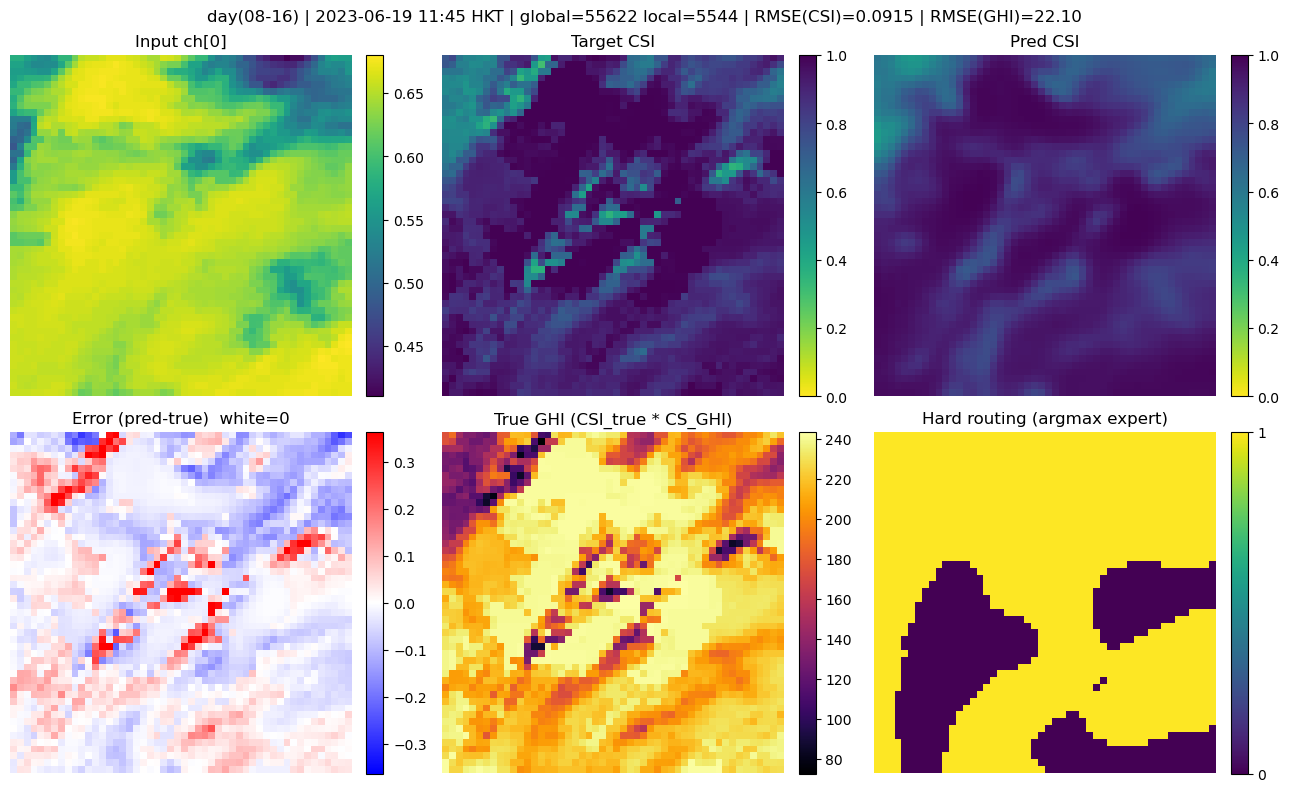

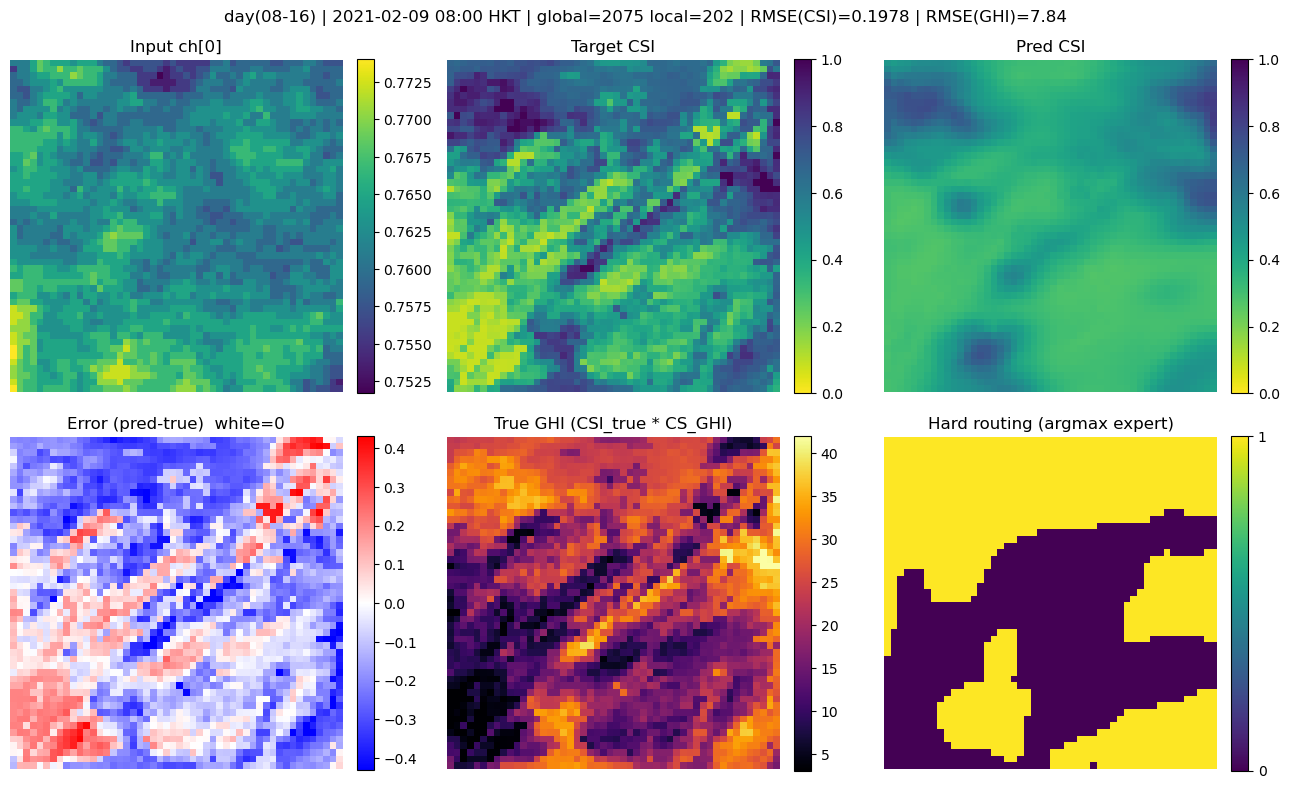

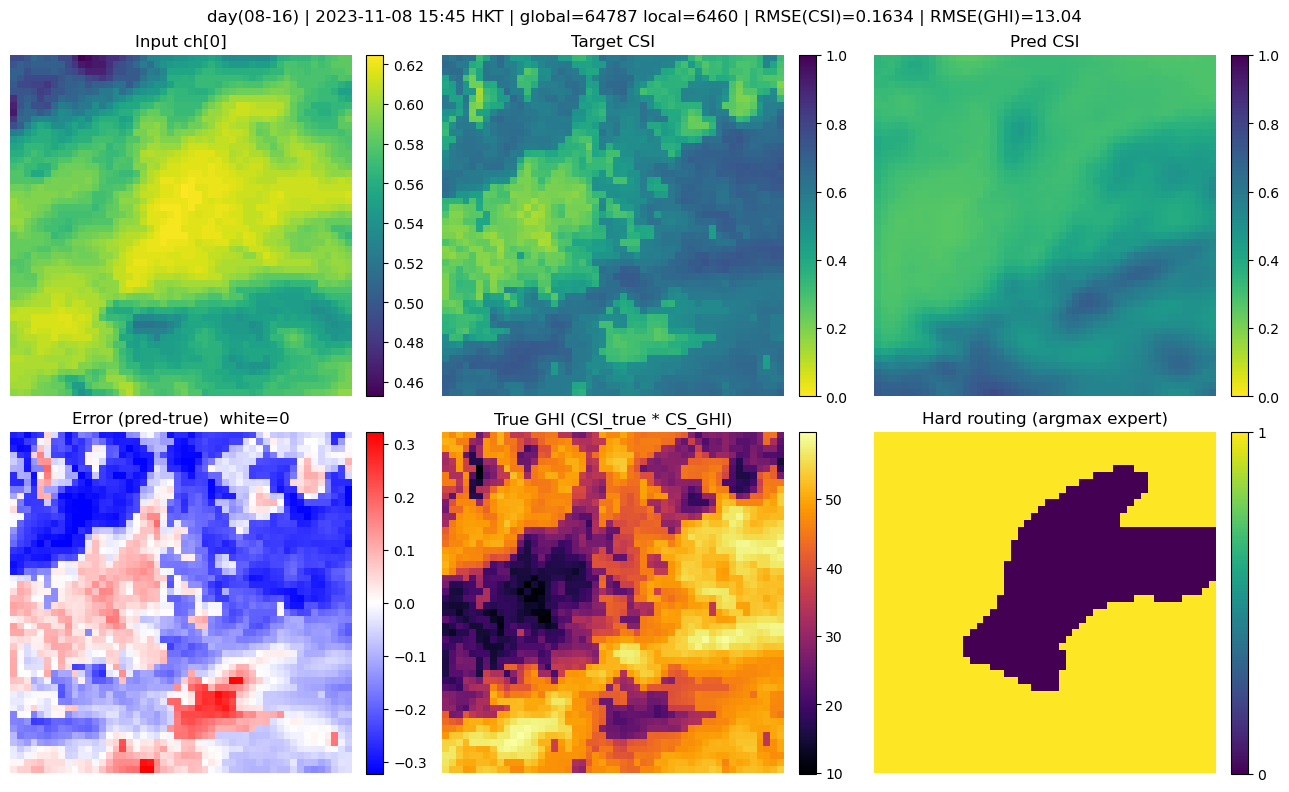

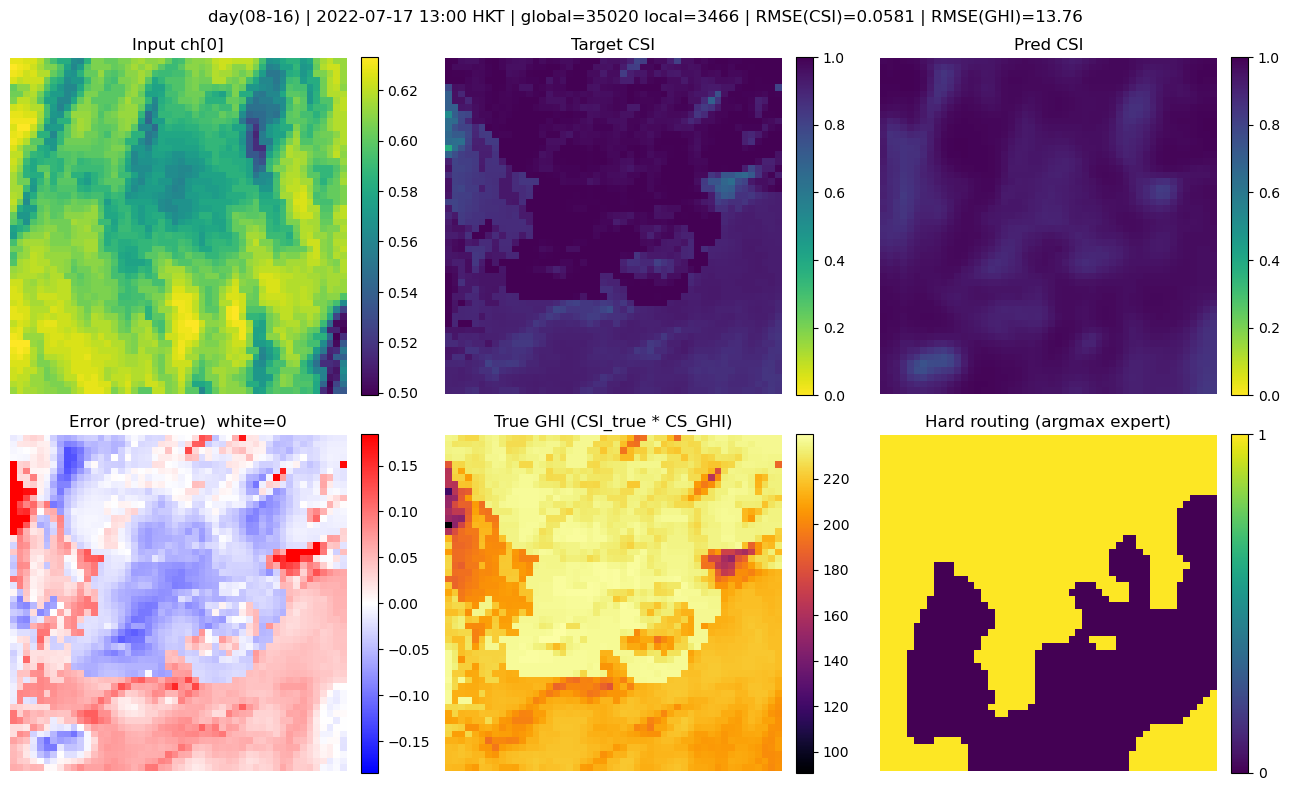

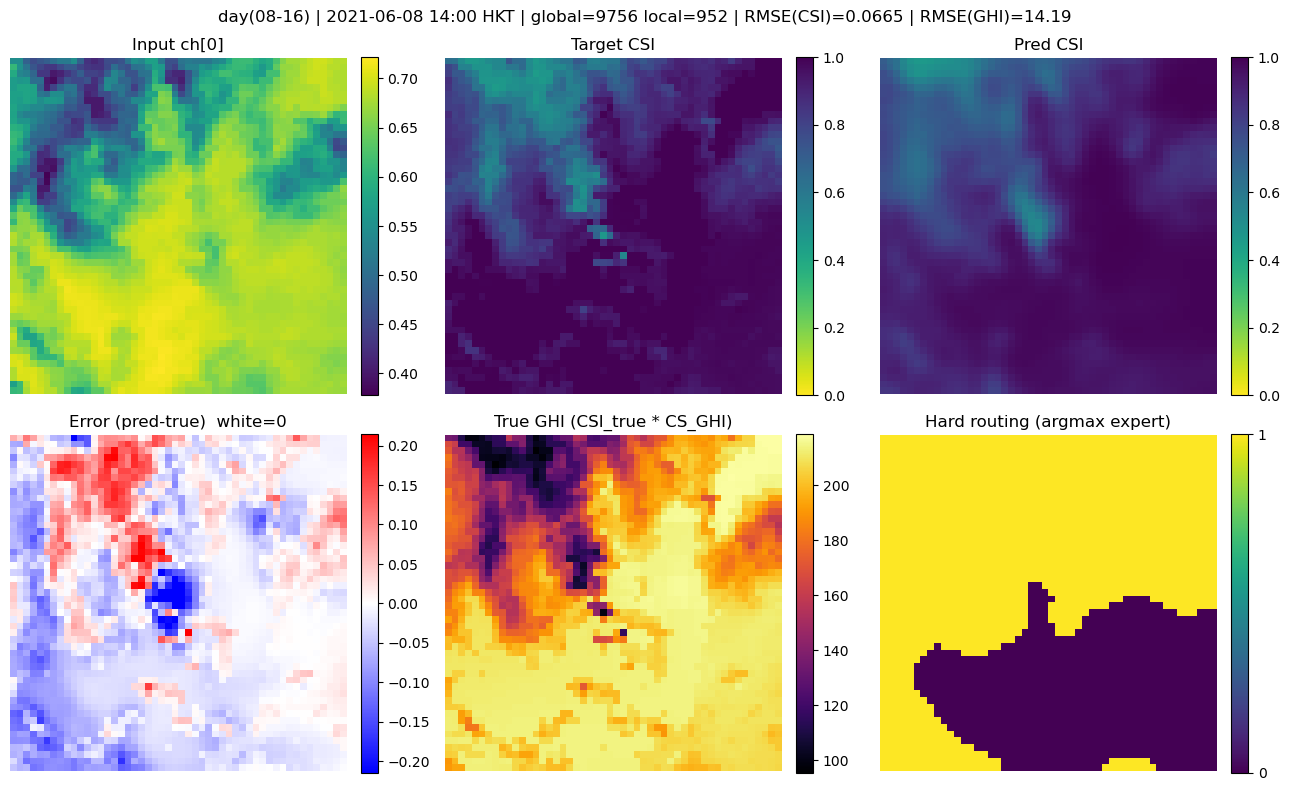

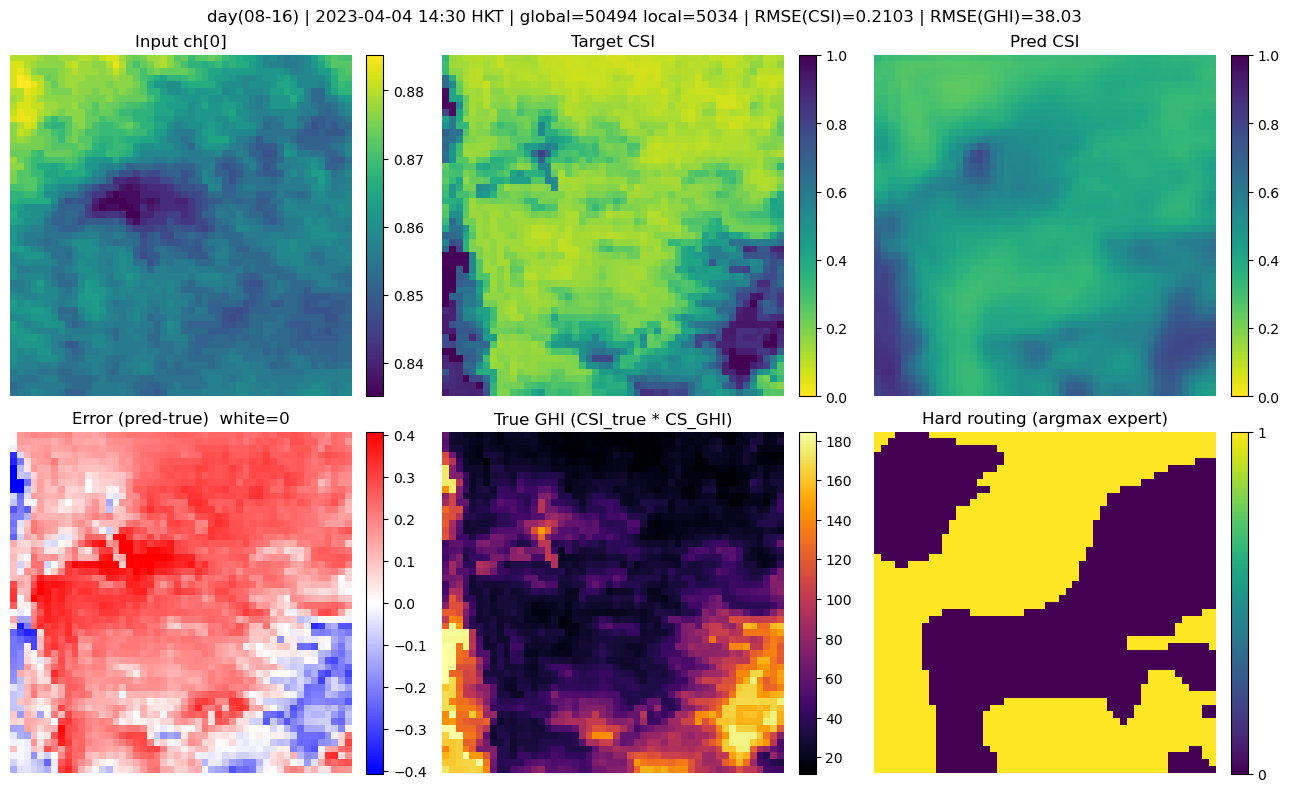

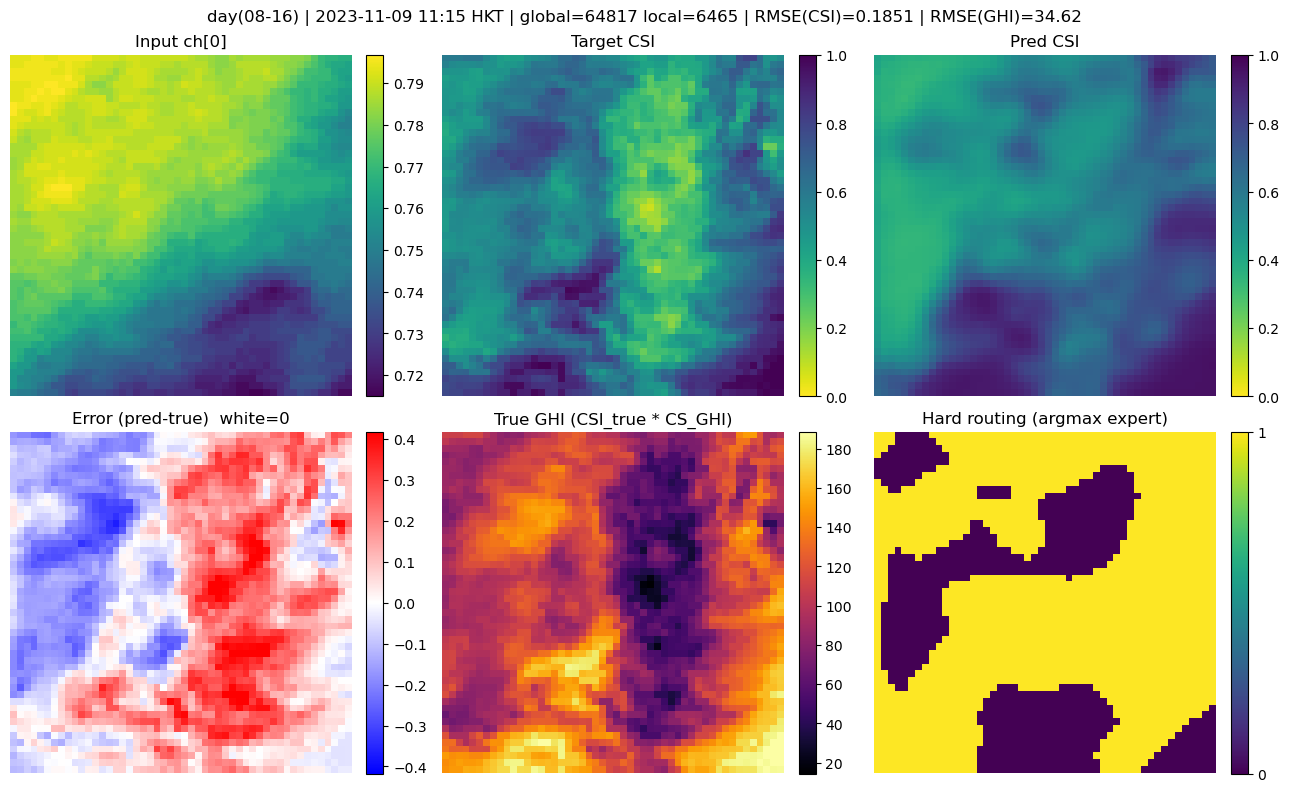

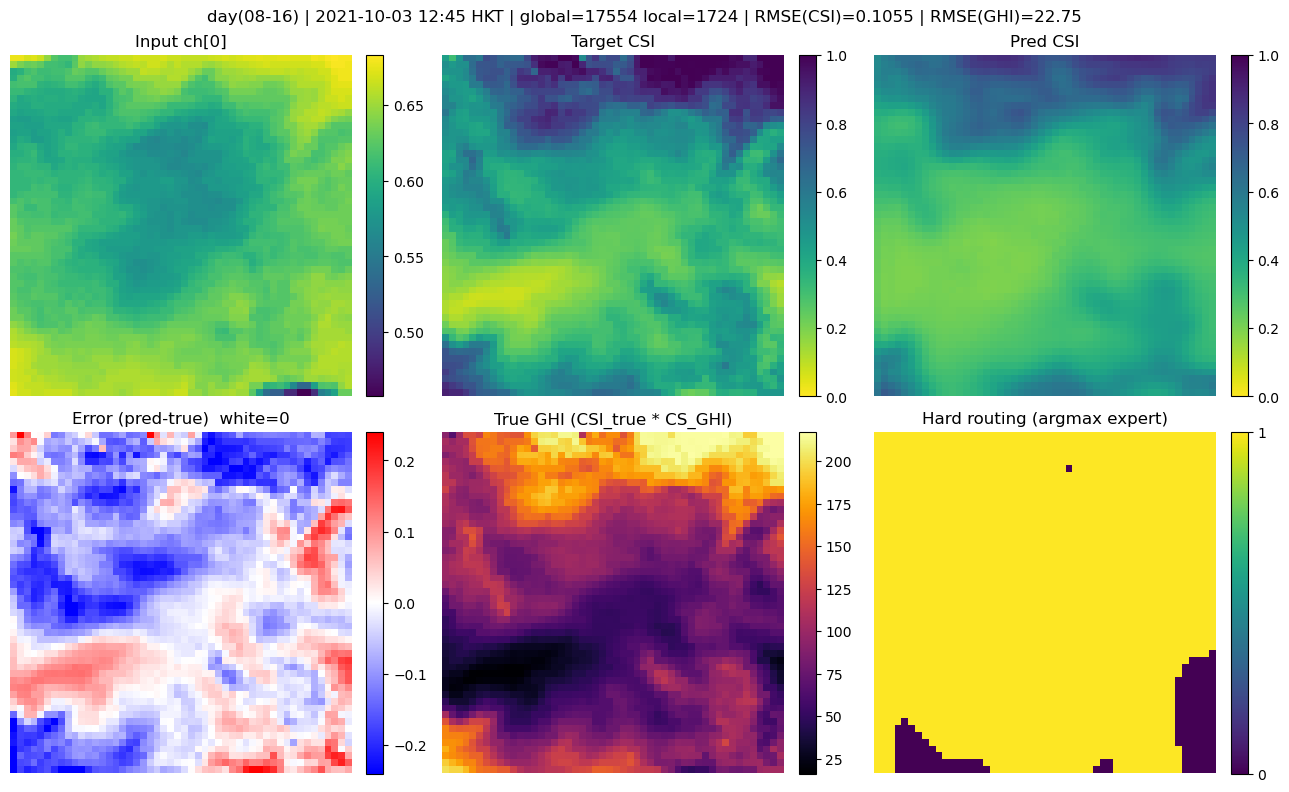

In [36]:
for i in day_local[:50]:
    plot_moe_sample_simple(
        model, test_dataset, i, device,
        time_mins=time_mins, idx_test=idx_test,
        cs_ghi_full=c1,            # <-- clear-sky GHI map per sample (global),
        bucket_name="day(08-16)",
        x_vis_ch=0,
        cmap_csi="viridis_r"
    )

In [ ]:
for i in evening_local[:50]:
    plot_moe_sample_simple(
        model, test_dataset, i, device,
        time_mins=time_mins, idx_test=idx_test,
        cs_ghi_full=c1,            # <-- clear-sky GHI map per sample (global)
        bucket_name="morning(05-08)",
        x_vis_ch=0,
        cmap_csi="viridis_r"
    )


In [38]:
metrics = evaluate_csi_ghi(
    model, test_loader, device,
    cs_ghi_full=c1,      # your clear-sky GHI map per global sample (T,H,W) or (T,1,H,W)
    idx_eval=idx_test,   # global indices for the test split, in the same order as test_dataset/test_loader
    clear_thr=0.80,
    cloudy_thr=0.35
)
print(metrics["CSI"])
print(metrics["GHI"])
print("clear GHI RMSE:", metrics["GHI_clear"]["RMSE"])
print("cloudy GHI RMSE:", metrics["GHI_cloudy"]["RMSE"])


{'RMSE': 0.1307211498339351, 'MAE': 0.08476977059022894, 'MBE': 0.00920058835577181, 'R2': 0.8262331387856425, 'mean_true': 0.6985294022523689, 'n_pixels': 16885000}
{'RMSE': 19.57569523224861, 'MAE': 11.767491832617708, 'MBE': 1.8850102390134549, 'R2': 0.9172362277956592, 'mean_true': 102.6826789458099, 'n_pixels': 16885000}
clear GHI RMSE: 13.381469323181825
cloudy GHI RMSE: 23.345097838443362


In [ ]:
14.3*4